# **BÀI TẬP 1: THỐNG KÊ MÁY TÍNH VÀ ỨNG DỤNG**

##### **Họ và tên**: Lý Liên Hoa
##### **MSSV**: 22127117

---
### **Câu 1.**
An và Bình cùng chơi một trò chơi gồm nhiều ván. Ai được 10 điểm trước thì người đó thắng trò chơi. Mỗi ván chỉ có 1 người thắng. Giả sử các ván độc lập và xác suất An thắng mỗi ván là 0.6.

**a.** Tính xác suất An thắng trò chơi nếu người thắng mỗi ván được 2 điểm.

**b.** Như (a) và nếu người thắng cũng thắng ván ngay trước đó thì được thêm 1 điểm.

**c.** Tính trung bình số ván cần chơi để An thắng trong (a) và (b).

----

##### **a. Tính xác suất An thắng trò chơi nếu người thắng mỗi ván được 2 điểm**

Gọi $n$ là  tổng số ván cần chơi, $A$ là biến cố "An thắng"

Các ván độc lập với nhau, mỗi ván chỉ có An thắng hoặc Bình thắng. Mỗi ván sẽ tuân theo phân phối **Bernoulli**. Với xác suất An thắng mỗi ván là 
$$
p = 0.6
$$

Và xác suất Bình thắng mỗi ván là
$$
q = 1 - p = 0.4
$$


Để thắng trò chơi với người thắng mỗi ván được 2 điểm thì An cần phải thắng $r$ ván, sao cho 
$$
2r = 10 \Rightarrow r = 5
$$

Gọi $k$ là số ván Bình thắng.
Để An thắng trò chơi, thì 
$$
k \in [0, 4]
$$

$\to$ Tổng số ván cần chơi là: 
$$
n = k + 5
$$

Xác suất để An thắng trò chơi trong $n$ ván:
$$
P(A) = \sum_{k=0}^4 C_{k + r - 1}^{k} p^r q^{k} = \sum_{k=0}^4 C_{k + 4}^{k} p^5 q^{k} \approx 0.7334
$$


In [1]:
import random
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
def probability_An_wins_the_game(p = 0.6):
    q = 1 - p
    result = 0
    
    for k in range (5):
        result += math.comb(k + 4, k) * (p**5) * (q**k)
        
    return result

In [3]:
probability_An_wins_the_game()

0.7334323199999999

**Mô phỏng**

In [4]:
def simulate_game_a(p = 0.6, simulations = 100000):
    games_an_wins = 0
    
    for _ in range(simulations):
        an_scores, binh_scores = 0, 0
        
        while an_scores < 10 and binh_scores < 10:
            if np.random.random() < p:
                an_scores += 2
            else:
                binh_scores += 2
                
        if an_scores >= 10:
            games_an_wins += 1
        
    
    return games_an_wins / simulations
        

In [5]:
simulate_game_a(p=0.6, simulations=300000)

0.7343566666666667

##### **b. Như (a) và nếu người thắng cũng thắng ván ngay trước đó thì được thêm 1 điểm.**

Gọi $a$, $b$ lần lượt là tổng điểm hiện tại của An và Bình. 

Gọi $x$ là trạng thái biểu diễn người thắng trước $(x \in [0, 2])$

$S$ là tập hợp các trạng thái trong trò chơi:
$$
S = \{(a, b, x): 0 \le a, b \le 10; 0 \le x \le 2 \}
$$


- Nếu x = 0 (Trạng thái ban đầu $(a, b, 0)$):
    - Nếu An thắng, sẽ chuyển sang trạng thái: $(a + 2, b, 1)$
    - Nếu Bình thắng, sẽ chuyển sang trạng thái: $(a, b + 2, 2)$

- Nếu x = 1 (An thắng ván trước):
    - Nếu An thắng, sẽ chuyển sang trạng thái: $(a + 3, b, 1)$
    - Nếu Bình thắng, sẽ chuyển sang trạng thái: $(a, b + 2, 2)$

- Nếu x = 2 (Bình thắng ván trước):
    - Nếu An thắng, sẽ chuyển sang trạng thái: $(a + 2, b, 1)$
    - Nếu Bình thắng, sẽ chuyển sang trạng thái: $(a, b + 3, 2)$

Gọi $P(a, b, x)$ là xác suất An thắng trò chơi từ trạng thái $(a, b, x)$
- Nếu $10 \le a \le 12 \to P(a, b, x) = 1$
- Nếu $10 \le b \le 12 \to P(a, b, x) = 0$
- Nếu $a < 10$ và $b < 10$:
    - Nếu $x = 0$:
    $$
    P(a, b, 0) = 0.6 \cdot P(a + 2, b, 1) + 0.4 \cdot P(a, b + 2, 2)
    $$

    - Nếu $x = 1$:
    $$
    P(a, b, 1) = 0.6 \cdot P(a + 3, b, 1) + 0.4 \cdot P(a, b + 2, 2)
    $$

    - Nếu $x = 2$:
    $$
    P(a, b, 2) = 0.6 \cdot P(a + 2, b, 1) + 0.4 \cdot P(a, b + 3, 2)
    $$

Phân phối trạng thái ban đầu: $\pi_{0} = (0, 0, 0)$

Để An thắng trò chơi thì phân phối trạng thái sau n ván: $\pi_{n} = (a, b, x) = P^n \cdot \pi_0$, với $a \ge 10, b \in [0, 9],$ và $x \in [0, 2]$

Xác suất để An thắng trò chơi là:
$$
P = \sum_{b = 0}^{9} \sum_{x = 0}^{2} \pi_{n}((a, b, x))
$$
Với $a \ge 10$

In [6]:
def probability_An_wins_the_game_extra_points(p = 0.6, n = 100):
    
    # Trạng thái
    states = [(a, b, x) for a in range(13) for b in range(13) for x in range(3)]
    q = 1 - p
    
    def get_state_index(a, b, x):
        return states.index((a, b, x))
    
    pi_0 = np.zeros(len(states))
    pi_0[get_state_index(0, 0, 0)] = 1
        
    P = np.zeros((len(states), len(states)))
    
    
    for a in range(13):
        for b in range(13):
            for x in range(3):
                current_state = get_state_index(a, b, x)
                
                if a >= 10:
                    P[current_state, current_state] = 1
                    continue
                
                if b >= 10:
                    continue
                
                if x == 0:  # Không ai thắng liên tiếp   
                    P[current_state, get_state_index(a + 2, b, 1)] += p
                    P[current_state, get_state_index(a, b + 2, 2)] += q
                        
                elif x == 1:  # An thắng ván trước
                    P[current_state, get_state_index(a + 3, b, 1)] += p
                    P[current_state, get_state_index(a, b + 2, 2)] += q
                        
                elif x == 2:  # Bình thắng ván trước
                    P[current_state, get_state_index(a + 2, b, 1)] += p
                    P[current_state, get_state_index(a, b + 3, 2)] += q
     
    # Tính pi^n                   
    pi_n = pi_0.copy()
    for _ in range(n):
        pi_n = np.dot(pi_n, P)
        
    an_win_probability = sum(pi_n[get_state_index(a, b, x)] for a in range(10, 13) for b in range(10) for x in range(3))
    
    return an_win_probability
 

In [7]:
probability_An_wins_the_game_extra_points()

0.7188341759999999

**Mô phỏng**

In [8]:
def simulate_game_b(p = 0.6, simulations = 100000):
    games_an_wins = 0
    
    for _ in range(simulations):
        an_scores, binh_scores = 0, 0
        previous_winner = None
        
        while an_scores < 10 and binh_scores < 10:
            if np.random.random() < p:
                if previous_winner == 1:
                    an_scores += 3
                else:
                    an_scores += 2
                    
                previous_winner = 1
                    
            else:
                if previous_winner == 2:
                    binh_scores += 3
                else:
                    binh_scores += 2
                
                previous_winner = 2
                    
        if an_scores >= 10:
            games_an_wins += 1
            
    return games_an_wins / simulations

In [9]:
simulate_game_b(0.6)

0.71851

##### **c. Tính trung bình số ván cần chơi để An thắng trong (a) và (b).**

- **Trung bình số ván cần chơi để An thắng trong (a)**
    - Tổng số ván cần chơi: $n = r + k = 5 + k, k \in [0, 4], n \in [5, 9] $
    - Để An thắng trò chơi ở ván thứ $n$, thì ở $(n - 1) $ ván đầu An phải thắng 4 ván. Xác suất để An thắng 4 ván trong $(n - 1)$ ván sẽ tuân theo phân phối **Nhị thức**:
    $$
    P(n - 1) = C_{4}^{n - 1} \cdot p^4 \cdot q^{n - 5}
    $$
    - Xác suất An thắng ván thứ n:
    $$
    P(n) = P(n - 1) \cdot p = C_{4}^{n- 1} \cdot p^5 \cdot q^{n - 5}
    $$
    - Kì vọng số ván An thắng:
    $$
    E[A] = \sum_{n = 5}^{9} n P(n) \approx 5 \cdot 0.07776  + 6 \cdot 0.15552 + 7 \cdot 0.186624 + 8 \cdot 0.1741824 + 9 \cdot 0.13934592 \approx 5.27586
    $$
    - Ta có xác suất số ván An thắng (được tính ở câu (a)): $P \approx 0.7334$
    $$
    \Rightarrow E[n|A] = \frac{E[A]}{P(A)} \approx 7.2
    $$

**Mô phỏng**

In [10]:
def simulate_average_round_game_a(p, simulations = 100000):
    total_rounds = 0
    an_wins_simulations = 0
    
    for _ in range(simulations):
        played_rounds = 0
        an_scores, binh_scores = 0, 0
        
        while an_scores < 10 and binh_scores < 10:
            played_rounds += 1
            
            if np.random.random() < p:
                an_scores += 2
            else:
                binh_scores += 2
        
        if an_scores >= 10:
            an_wins_simulations += 1
            total_rounds += played_rounds      
    
    return total_rounds / an_wins_simulations if an_wins_simulations > 0 else 0

In [11]:
simulate_average_round_game_a(0.6, 300000)

7.196588401107592

- **Trung bình số ván cần chơi để An thắng trong (b)**
    - Gọi $T(a, b, x)$ là tổng số ván kì vọng từ trạng thái hiện tại $(a, b, x)$ đến các trạng thái mà cuối cùng An thắng.
        - Nếu $a\ge 10$ hoặc $b \ge 10 \Rightarrow T(a, b, x) = 0$
        - Nếu $a, b < 10$:
        $$
        \begin{cases}
        T(a, b, 0) = P(a, b, 0) + 0.6 \cdot F(a + 2, b, 1) + 0.4 \cdot(a, b + 2, 2) \\
        T(a, b, 1) = P(a, b, 1) + 0.6 \cdot F(a + 3, b, 1) + 0.4 \cdot(a, b + 2, 2) \\
        T(a, b, 2) = P(a, b, 2) + 0.6 \cdot F(a + 2, b, 1) + 0.4 \cdot(a, b + 3, 2)
        \end{cases}
        $$
        - Trung bình số ván cần chơi để An thắng trong (b):
        $$
        E[n | A] = \frac{F(0, 0, 0)}{P(0, 0, 0)}
        $$
        Với: 
        - $P(0, 0, 0)$ là xác suất An thắng từ trạng thái ban đầu $(0, 0, 0)$  
        - $F(0, 0, 0)$ là tổng kỳ vọng số ván ở trường hợp An thắng từ trạng thái ban đầu $(0, 0, 0)$

**Mô phỏng**

In [12]:
def simulate_average_round_game_b(p, simulations = 100000):
    total_rounds = 0
    an_wins_simulations = 0
    
    for _ in range(simulations):
        played_rounds = 0
        an_scores, binh_scores = 0, 0
        previous_winner = None
        
        while an_scores < 10 and binh_scores < 10:
            played_rounds += 1
            
            if np.random.random() < p:
                if previous_winner == 1:
                    an_scores += 3
                else:
                    an_scores += 2
                    
                previous_winner = 1
                
            else:
                if previous_winner == 2:
                    binh_scores += 3
                else:
                    binh_scores += 2
                
                previous_winner = 2
        
        if an_scores >= 10:
            an_wins_simulations += 1
            total_rounds += played_rounds
            
    return total_rounds / an_wins_simulations if simulations > 0 else 0

In [13]:
simulate_average_round_game_b(0.6)

5.908096432552954

---- 

### **Câu 2.**

Cho $U$ là biến ngẫu nhiên có phân phối đều trên $(0, 1)$.  
**a.** Cho các số thực $a < b$, tìm phân phối của $a + (b - a)U$.  
**b.** Cho các số thực $0 < a < b < 1$, tìm phân phối của $U$ biết $a < u < b$.  
**c.** Cho $V$ cũng là biến ngẫu nhiên có phân phối đều trên $(0, 1)$, tìm phân phối của max $\{U, V\}$.  


----

##### **a. Cho các số thực $a < b$, tìm phân phối của $a + (b - a)U$.**

$U$ là biến ngẫu nhiên có phân phối đều trên $(0, 1)$, nên ta có hàm phân phối của $U$:
$$
F_{U}(u) = P(U \le u) = 
\begin{cases}
0 & \text{nếu } u \le 0 \\
u & \text{nếu } 0 < u < 1 \\
1 & \text{nếu } u \ge 1
\end{cases}
$$

$\text{Đặt } X = a + (b - a)U \text{, với } a < b$

Vì $U \in (0, 1)$ nên
$$
X \in (a + (b - a) \cdot 0, a + (b - a) \cdot 1)
\Rightarrow X \in (a, b)
$$

Hàm phân phối của X được xác định bởi:
$$
F_{X}(x) = P(X \le x) = P(a + (b - a)U \le x) = P(U \le \frac{x - a}{b - a})
$$

Xét các trường hợp của $x$:
- Nếu $x \le a \text{ thì } \frac{x - a}{b - a} \le 0$. Từ đây, ta suy ra:
$$
F_{X}(x) = P(U \le \frac{x - a}{b - a}) = 0
$$
- Nếu $ a < x < b \text{ thì } \frac{x - a}{b - a} \in (0, 1)$. Từ đây, ta suy ra:
$$
F_{X}(x) = P(U \le \frac{x - a}{b - a}) = \frac{x - a}{b - a}
$$
- Nếu $x \ge b \text{ thì } \frac{x - a}{b - a} \ge 1$. Từ đây, ta suy ra:
$$
F_{X}(x) = P(U \le \frac{x - a}{b - a}) = 1
$$

Từ đó ta có:
$$
F_{X}(x) = 
\begin{cases}
0 & \text{nếu } x \le a \\
\frac{x - a}{b - a} & \text{nếu } a < x < b \\
1 & \text{nếu } x \ge b
\end{cases}
$$

Lấy đạo hàm của hàm phân phối, ta có hàm mật độ xác suất:
$$
f_{X}(x) = F_{X}^{'}(x) = 
\begin{cases}
\frac{1}{b - a} & \text{nếu } a < x < b \\
0 & \text{khác}
\end{cases}
$$

**Mô phỏng**

In [14]:
def generate_smaller_a_b(start_a = -10, end_a = 10):
    a = np.random.uniform(start_a, end_a)
    b = None
    while b is None or b < a:
        b = np.random.uniform(a + 1, a + end_a)
        
    return a, b
    

def question_2a(a, b, simulations = 100000):
    U = np.random.uniform(size=simulations)
    X = a + (b - a) * U
    return X

def plot_question_2a(a, b, simulations=100000):
    plt.figure(figsize=(12, 6))
    plt.hist(question_2a(a, b), bins=20, density=True, edgecolor='black')
    plt.xlabel('X')
    plt.ylabel('Density')
    plt.axhline(y=1/(b - a), color='r', linestyle='--', label='Theoretical PDF')
    plt.title(f"Approximate $X = a + (b - a) \cdot U, \; (a < b),$ with( ($a = {a:.2f}, b = {b:.2f}$) by histogram (Simulations = {simulations})")
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
C:\Users\admin\AppData\Local\Temp\ipykernel_14660\2840750173.py:21: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f"Approximate $X = a + (b - a) \cdot U, \; (a < b),$ with( ($a = {a:.2f}, b = {b:.2f}$) by histogram (Simulations = {simulations})")


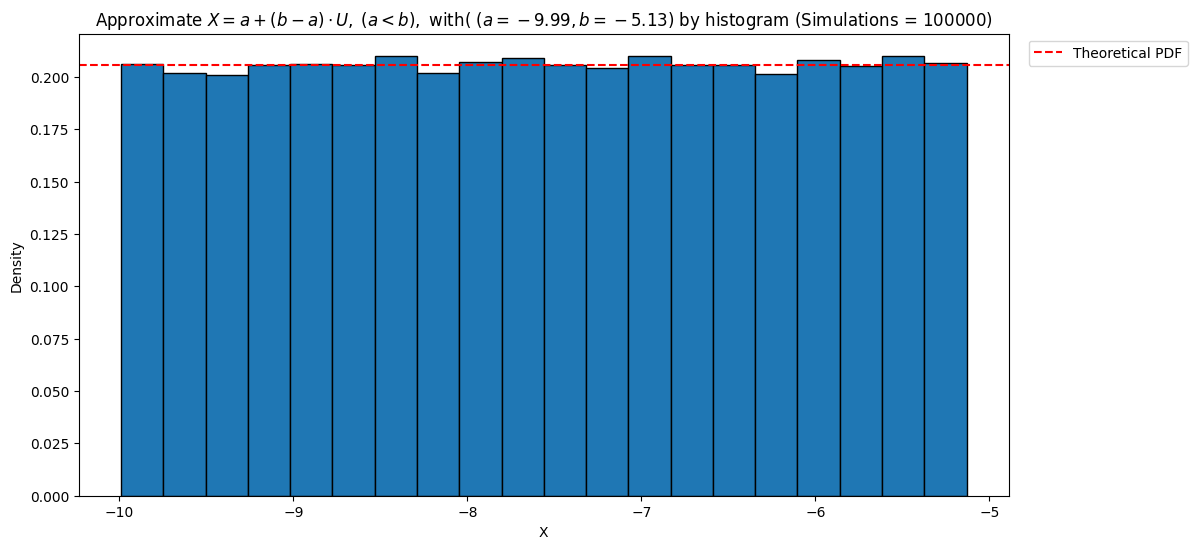

In [15]:
a, b = generate_smaller_a_b()
plot_question_2a(a, b)

##### **b. Cho các số thực $0 < a < b < 1$, tìm phân phối của $U$ biết $a < U < b$.**

Ta có: $U$ là biến ngẫu nhiên có phân phối đều trên $(0, 1)$, nên  $U$ có hàm mật độ xác suất sau:
$$
f(u) = 
\begin{cases}
1 & \text{nếu } 0 < u < 1 \\
0 & \text{khác}
\end{cases}
$$

Và theo đề ta có $a < U < b$ và $ 0 < a < b < 1$, xác suất để $a < U < b$:
$$
P(a < U < b) = \int_{a}^{b}f(u)du = \int_{a}^{b}1du = b - a
$$


Hàm phân phối của $U$, có điều kiện $a < U < b$ được xác định bởi:
$$
F_{U|(a < U < b)}(x) = P(U \le x | a < U < b) = \frac{P(a < U \le x)}{P(a < U < b)}
$$

Xét các trường hợp của u:
- Nếu $x \le a$, thì $(a < U \le x) = \varnothing$. Lúc này:
$$
P(a < U \le x) = 0
$$

- Nếu $a < x < b$:
$$
P(a < U < x) = \int_{a}^{x}f(u)du = \int_{a}^{x}1du= x - a
$$

- Nếu $x \ge b \text{ hay } x \in [b, \infty)$:
$$
P(a < U < x) = \int_{a}^{x}f(u)du = \int_{a}^{b}f(u)du + \int_{b}^{x}f(u)du = \int_{a}^{b}1du + \int_{b}^{x}0du = b - a
$$

Từ đó, ta có:
$$
F_{U|(a < U < b)}(x) = 
\begin{cases}
0 & \text{nếu } x \le a \\
\frac{x - a}{b - a} & \text{nếu } a < x < b \\
1 & \text{nếu } x \ge b
\end{cases}
$$

Lấy đạo hàm của hàm phân phối, ta có hàm mật độ xác suất:
$$
f_{U|(a < U < b)}(x) = F_{U|(a < U < b)}^{'}(x) = 
\begin{cases}
\frac{1}{b - a} & \text{nếu } a < x < b \\
0 & \text{khác}
\end{cases}
$$

**Mô phỏng**

In [16]:
def question_2b(a, b, simulations = 100000):
    conditional_U = np.random.uniform(a, b, size=simulations)
    return conditional_U

def plot_question_2b(a, b, simulations=100000):
    plt.figure(figsize=(12, 6))
    plt.hist(question_2b(a, b), bins=20, density=True, edgecolor='black')
    plt.xlabel('U')
    plt.ylabel('Density')
    plt.axhline(y=1/(b - a), color='r', linestyle='--', label='Theoretical PDF')
    plt.title(f"Approximate $U$ when $0 < a < U < b < 1,$ with ($a = {a:.2f}, b = {b:.2f}$) by histogram (Simulations = {simulations})")
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.show()

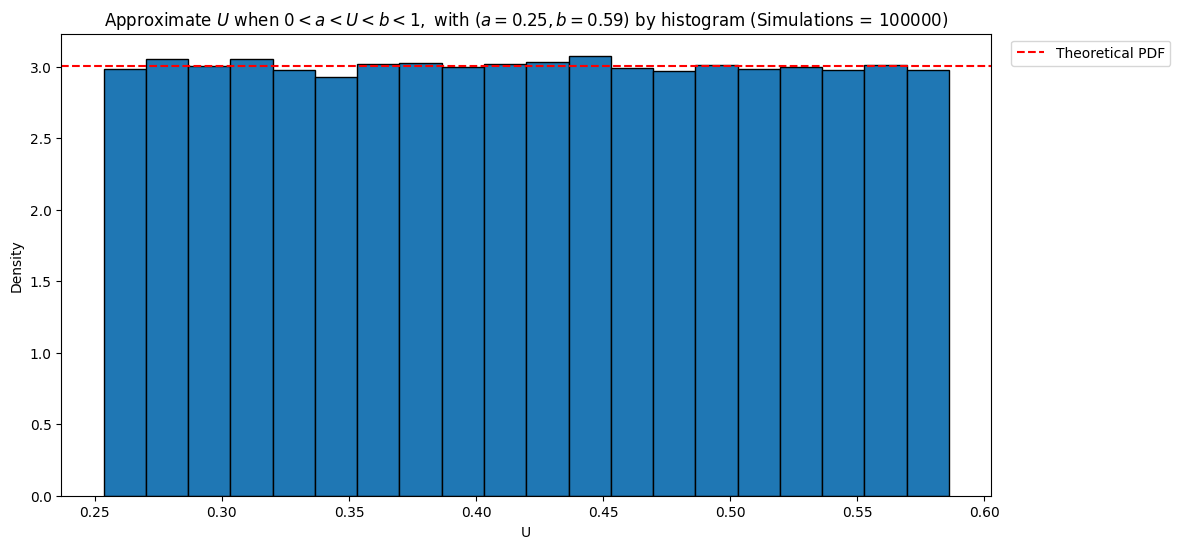

In [17]:
a = random.uniform(0, 1)
b = random.uniform(a, 1)
    
plot_question_2b(a, b)

##### **c. Cho $V$ cũng là biến ngẫu nhiên có phân phối đều trên $(0, 1)$, tìm phân phối của $max\{U, V\}$.**

Gọi biến ngẫu nhiên $W = max\{U, V\}$, hàm phân phối của W là:
$$
F_{W}(w) = P(W \le w) = P(max\{U, V\} \le w), w \in (0, 1)
$$

Xét các trường hợp của $w$:
- Nếu $w \le 0$ thì $(max\{U, V\}) = \varnothing$, vì $0 \le U, W \le 100$, nên
$$
P(W \le w) = 0
$$

- Nếu $0 < w < 1$: Vì $U$ và $V$ đều là biến ngâu nhiên có phân phối đều trên $(0, 1)$ nên ta có:
    - Nếu $max\{U, V\} = U$ thì:
    $$
    P(U \le w) = w
    $$
    - Nếu $max\{U, V\} = V$ thì:
    $$
    P(V \le w) = w
    $$
    Do đó:
    $$
    P(W \le w) = P(max\{U, V\} \le w) = P(U \le w, V \le w) = P(U \le w) \cdot P(V \le w) = w^2
    $$
    $U, V$ là 2 biến ngẫu nhiên độc lập

- Nếu $w \ge 1$ thì $max\{U, V\} \le 1$ do $U, V \in (0, 1)$, nên
$$
P(W \le w) = 1
$$

Từ đó, ta có:
$$
F_{W}(w) = 
\begin{cases}
0 & \text{nếu } w \le 0 \\
w^2 & \text{nếu } 0 < w < 1 \\
1 & \text{nếu } w \ge 1
\end{cases}
$$

Lấy đạo hàm của hàm phân phối, ta có hàm mật độ xác suất:
$$
f_{W}(w) = F_{W}^{'}(w) = 
\begin{cases}
2w & \text{nếu } 0 < w < 1 \\
0 & \text{khác}
\end{cases}
$$

**Mô phỏng**

In [18]:
def question_2c(simulations = 100000):
    U = np.random.uniform(0, 1, simulations)
    V = np.random.uniform(0, 1, simulations)
    W = np.maximum(U, V)
    return W

def plot_question_2c(w, simulations=100000):
    w_vals = np.linspace(0, 1, 1000)
    f_W = 2 * w_vals
    plt.figure(figsize=(12, 6))
    plt.hist(w, bins=30, density=True, edgecolor='black')
    plt.xlabel('W')
    plt.ylabel('Density')
    plt.plot(w_vals, f_W, 'r--', label='Theoretical PDF')
    plt.title(f"Approximate $W = max({{U, V}})$ by histogram (Simulations = {simulations})")
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.show()

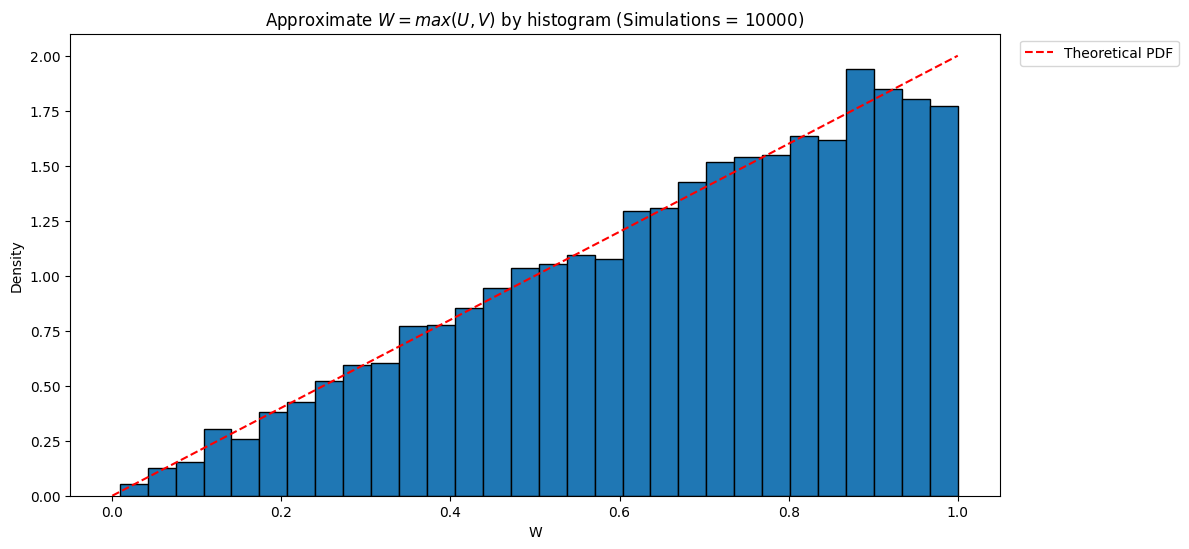

In [19]:
N = 10000
w = question_2c(N)
plot_question_2c(w,N)

----

### **Câu 3.**

Chọn ngẫu nhiên 2 điểm $A, B$ trong $S = [0, 1]^{k}$. Gọi $D$ là khoảng cách giữa $A, B$.  
**a.** Tính $E(D)$ khi $k$ = 1  
**b.** Tính $E(D)$ khi $k$ = 2  
**c.** Khảo sát $r_{k} = \frac{E(D)}{\sqrt{k}}$ theo $k = 1, 2, … , 10$  


---

##### **a. Tính $E(D)$ khi $k$ = 1**

$S = [0, 1]$

$D$ là khoảng cách giữa $A$ và $B$ $\Rightarrow D = |A - B|$  
Gọi $X, Y$ lần lượt là tọa độ của $A, B$ trên đoạn thẳng $[0, 1]$ thì $X, Y ~ U(0, 1)$.  
Hàm mật độ xác suất của $X, Y$ là:
$$
f_{x}(X) = 1, \quad x \in (0, 1)\\
f_{y}(Y) = 1, \quad y \in (0, 1)
$$
Với $A, B$ là 2 biến ngẫu nhiên, độc lập, liên tục trên đoạn $[0, 1], \; D \in [0, 1]$ 
$$
\Rightarrow \quad f_{XY}(x, y) = f_{X}(x) \cdot f_{Y}(y) = 1 \cdot 1 = 1
$$
Hàm phân phối của D có dạng:
$$
F_{D}(d) = P(D \le d) = P(|A - B| \le d)
$$

**Minh họa**

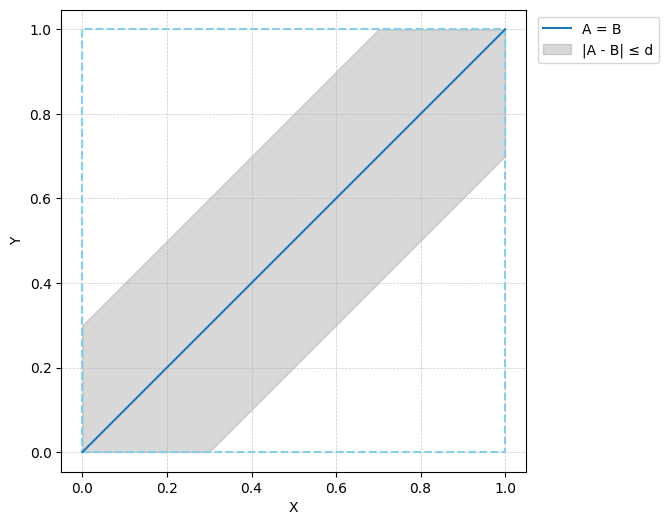

In [20]:
# VẼ TRỤC TỌA ĐỘ
plt.figure(figsize=(6,6))

# Hình vuông 1 x 1
square_x = [0, 1, 1, 0, 0]
square_y = [0, 0, 1, 1, 0]
plt.plot(square_x, square_y, color='skyblue', linestyle='--')

# Đường chéo
plt.plot([0, 1], [0, 1], label='A = B')

D = 0.3
x = np.linspace(0, 1, 500)
# Tính các giá trị y cho đường y = x + D và y = x - D
y_upper = x + D
y_lower = x - D

# Giới hạn các giá trị y trong khoảng [0,1]
y_upper = np.clip(y_upper, 0, 1)
y_lower = np.clip(y_lower, 0, 1)

# Tô màu vùng |A - B| ≤ D
plt.fill_between(x, y_lower, y_upper, where=(y_upper >= y_lower), color='gray', alpha=0.3, label=f'|A - B| ≤ d')


plt.xlabel('X')
plt.ylabel('Y')

plt.axis('equal')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.show()


Vì $|A - B|$ có tính đối xứng nên ta có độ dài của các cạnh góc vuông của 2 tam giác vuông đối xứng nhau mà không thõa $|A - B| \le d$ là $1 - d$  
$\Rightarrow$ Tổng diện tích của 2 tam giác đó là: 
$$
2 \cdot \frac{(1 - d)^2}{2} = (1 - d)^2
$$  
$\Rightarrow$ Diện tích vùng thõa mãn $|A - B| \le d$: 
$$
F_{D}(d) = 1 - (1 - d)^2 = 2d - d^2
$$
$\Rightarrow$ Hàm mật độ xác suất của D:
$$
f_{D}(d) = F_{D}^{'}(d)= 2 - 2d, \quad \text{với } 0 \le d \le 1
$$


Ta có kì vọng của $D$:
$$
E(D) = \int_{0}^{1} = d \cdot f_{D}(d)dd = 2 \cdot \int_{0}^{1}d - d^2 = 2 \cdot \left(\frac{d^2}{2} - \frac{d^3}{3}\right) \Big|_{0}^{1} = \frac{1}{3} \approx 3,33
$$

**Mô phỏng**

In [21]:
def generate_a_b_3a(simulations=100000):
    a = np.random.uniform(size=simulations)
    b = np.random.uniform(size=simulations)
    return a, b

def cal_distance_1(a, b):
    dist = abs(a - b)
    return dist

def simulate_average_distance_1(simulations=100000):
    a, b = generate_a_b_3a(simulations)
    distances = cal_distance_1(a, b)
    return distances.mean()
    

In [22]:
simulate_average_distance_1(500000)

0.3335505110044565

##### **b. Tính $E(D)$ khi $k$ = 2**

$S = [0, 1]^2 = \{(x, y) \; | \; x \in [0, 1] \text{ và } y \in [0, 1]\}$ - hình vuông có độ dài 1 trong mặt phẳng 2 chiều $Oxy$

Có $A = (x_1, y_1)$ và $B = (x_2, y_2)$ là 2 điểm ngẫu nhiên, độc lập trong $S$  
Ta có khoảng cách $D$ giữa $A$ và $B$:
$$
D = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}
$$
Đặt $U = |x_2 - x_1|,\; V = |y_2 - y_1| \; (U, V \in [0, 1])$
$$
\Rightarrow \quad D = \sqrt{U^2 + V^2}, \quad D \in [0, \sqrt{2}]
$$

Ta có: $U = |x_2 - x_1|$ với $U \in [0, 1], \text{ và } x_1, x_2 \in [0, 1]$  
Dựa vào câu (a) ta có hàm mật độ xác xuất của $U$:
$$
f_{U}(u) = 2 - 2u, \text{ với } 0 \le u \le 1
$$
Tương tự ,ta có hàm mật độ xác suất của $V$:
$$
f_{V}(v) = 2 - 2v, \text{ với } 0 \le v \le 1
$$

Vì $U, V$ là 2 biến ngẫu nhiên, độc lập trên $[0, 1]$ nên:
$$
f_{UV}(u, v) = f_{U}(u) \cdot f_{V}(v) = (2 - 2u)(2 - 2v) = 4 - 4(u + v) + 4uv, \quad \text{với } 0 \le u, v \le 1
$$

Kì vọng của D:
$$
E(D) = \int_{0}^{\sqrt{2}} d \cdot f_{D}(d)dd
     = \int_{0}^{1}\int_{0}^{1} \sqrt{u^2 + v^2} \cdot f_{UV}(u, v)du\,dv
     = 4 \int_{0}^{1}\int_{0}^{1} \sqrt{u^2 + v^2} \cdot (1 - u - v + uv)du\,dv \\
     = 4 \left[ \int_{0}^{1}\int_{0}^{1} \sqrt{u^2 + v^2} - u \cdot \sqrt{u^2 + v^2} - v \cdot \sqrt{u^2 + v^2} + uv \cdot \sqrt{u^2 + v^2} \; du\,dv\right] \\
$$

Đặt $r = \sqrt{u^2 + v^2},\; r \in [0, \sqrt{2}]$  
$\Rightarrow u = r\cdot cos\theta, \, v = r\cdot sin\theta\;$ ($\theta$ là góc được tạo bởi trục hoành $Ox$ và $r$, $\theta \in [0, \frac{\pi}{2}]$)  
$$
\Rightarrow du\,dv = (\frac{\partial{u}}{\partial{r}} \cdot \frac{\partial{v}}{\partial{\theta}} - \frac{\partial{u}}{\partial{\theta}} \cdot \frac{\partial{v}}{\partial{r}})dr\,d\theta = cos\theta \cdot r\,cos\theta - (-r\,sin\theta) \cdot (sin\theta)dr\,d\theta
$$
$$
\Rightarrow du\,dv = r\,cos^{2}\theta + sin^{2}\theta \,dr\,d\theta= r\cdot(cos^{2}\theta + sin^{2}\theta)dr\,d\theta = rdr\,d\theta
$$

Và $u, v \in [0, 1]$
$$
\Rightarrow r \in \left[0, \frac{1}{cos\theta}\right] \quad \text{với } \theta \in [0, \frac{\pi}{4}]
$$

Hoặc
$$
r \in \left[0, \frac{1}{sin\theta}\right] \quad \text{với } \theta \in (\frac{\pi}{4}, \frac{\pi}{2}]
$$

$$
\Rightarrow
E(D) = 4\left[ \int_{0}^{1}\int_{0}^{1} \sqrt{u^2 + v^2} - u \cdot \sqrt{u^2 + v^2} - v \cdot \sqrt{u^2 + v^2} + uv \cdot \sqrt{u^2 + v^2} \; du\,dv \right] \\

     = 4\left[ \int_{0}^{\frac{\pi}{4}} \int_{0}^{\frac{1}{cos\theta}} r^2 - r^3 cos\theta -r^3 sin\theta + r^4 \cdot cos\theta sin\theta \; dr\,d\theta 
     + \int_{\frac{\pi}{4}}^{\frac{\pi}{2}} \int_{0}^{\frac{1}{sin\theta}} r^2 - r^3 cos\theta -r^3 sin\theta + r^4 \cdot cos\theta sin\theta \; dr\,d\theta\right] \\

     = 4 \left[ \int_{0}^{\frac{\pi}{4}} \left(\frac{r^3}{3} - \frac{r^4}{4}\cdot cos\theta - \frac{r^4}{4}\cdot sin\theta + \frac{r^5}{5}\cdot sin\theta cos\theta \right)\big|_{0}^{\frac{1}{cos\theta}} \; d\theta
     + \int_{\frac{\pi}{4}}^{\frac{\pi}{2}} \left(\frac{r^3}{3} - \frac{r^4}{4}\cdot cos\theta - \frac{r^4}{4}\cdot sin\theta + \frac{r^5}{5}\cdot sin\theta cos\theta \right)\big|_{0}^{\frac{1}{sin\theta}} \; d\theta \right]

$$

- Đặt $I_1 = \int_{0}^{\frac{\pi}{4}} \left(\frac{r^3}{3} - \frac{r^4}{4}\cdot cos\theta - \frac{r^4}{4}\cdot sin\theta + \frac{r^5}{5}\cdot sin\theta cos\theta \right)\big|_{0}^{\frac{1}{cos\theta}} \; d\theta$  
$$
\Rightarrow
I_1 = \int_{0}^{\frac{\pi}{4}} \frac{1}{3cos^{3}\theta} - \frac{1}{4cos^{3}\theta} - \frac{1}{4cos^{4}\theta} \cdot sin\theta + \frac{1}{5cos^{4}\theta} \cdot sin\theta \; d\theta
$$

$$
\Rightarrow 
I_1 = \frac{5\sqrt{2}\;ln(\sqrt{2} + 1) + 2 + 2\sqrt2}{120\sqrt{2}} \approx 0.065176 \quad (1)
$$


- Đặt $I_2 = \int_{\frac{\pi}{4}}^{\frac{\pi}{2}} \left(\frac{r^3}{3} - \frac{r^4}{4}\cdot cos\theta - \frac{r^4}{4}\cdot sin\theta + \frac{r^5}{5}\cdot sin\theta cos\theta \right)\big|_{0}^{\frac{1}{sin\theta}} \; d\theta $

$$
\Rightarrow
I_2 = \int_{\frac{\pi}{4}}^{\frac{\pi}{2}}
      \frac{1}{3sin^{3}\theta}
    - \frac{1}{4sin^{4}\theta} \cdot cos\theta
    - \frac{1}{4sin^{3}\theta}
    + \frac{1}{5sin^{4}\theta} \cdot cos\theta
    \; d\theta
$$

$$
\Rightarrow
I_2 = - \frac{-2\sqrt{2} - 5\; ln\left(\frac{1}{\sqrt{2} - 1} \right) \cdot \sqrt{2} - 2}{120\sqrt{2}} \approx 0.065176 \quad (2)
$$

Từ $(1)$ và $(2)$, ta có:
$$
E(D) = 4 \cdot (I_1 + I_2) 
     = 4 \cdot \left(\frac{5\sqrt{2}\;ln(\sqrt{2} + 1) + 2 + 2\sqrt2}{120\sqrt{2}} - \frac{-2\sqrt{2} - 5\; ln\left(\frac{1}{\sqrt{2} - 1} \right) \cdot \sqrt{2} - 2}{120\sqrt{2}} \right) \approx 0.5214
$$

**Mô phỏng**

In [23]:
def generate_3b(simulations=100000):
    x1 = np.random.uniform(size=simulations)
    y1 = np.random.uniform(size=simulations)
    
    x2 = np.random.uniform(size=simulations)
    y2 = np.random.uniform(size=simulations)
    return x1, y1, x2, y2

def cal_distance_2(x1, y1, x2, y2):
    u = x1 - x2
    v = y1 - y2
    dist = np.sqrt(u**2 + v**2)
    return dist

def simulate_average_distance_2(simulations=100000):
    x1, y1, x2, y2 = generate_3b(simulations)
    distances = cal_distance_2(x1, y1, x2, y2)
    return distances.mean()

In [24]:
simulate_average_distance_2()

0.5221867790661817

##### **c. Khảo sát $r_{k} = \frac{E(D)}{\sqrt{k}}$ theo $k = 1, 2, … , 10$**

**Mô phỏng**

In [25]:
def estimate_E_D(k, num_samples=1000000):
    A = np.random.uniform(0, 1, (num_samples, k))
    B = np.random.uniform(0, 1, (num_samples, k))
    
    D = np.linalg.norm(A - B, axis=1)

    E_D = np.mean(D)
    return E_D

In [26]:
def survey_3c(n=10):
    k_lists = []
    E_D_lists = []
    sqrt_k_lists = []
    r_k_lists = []

    for k in range(1, n + 1):
        # k
        k_lists.append(k)
        
        # E(D)
        E_D = estimate_E_D(k)
        E_D_lists.append(E_D)
        
        # sqrt(k)
        sqrt_k = np.sqrt(k)
        sqrt_k_lists.append(sqrt_k)
        
        # r_k
        r_k = E_D / sqrt_k
        r_k_lists.append(r_k)
        
    data = {
    'k': k_lists,
    'E(D)': E_D_lists,
    f"sqrt(k)": sqrt_k_lists,
    'r_k = E(D)/sqrt(k)': r_k_lists
    }
        
    df = pd.DataFrame(data)
    df.set_index('k', inplace=True)
    return df

In [27]:
print("Bảng khảo sát r_k")
survey_3c()


Bảng khảo sát r_k


,E(D),sqrt(k),r_k = E(D)/sqrt(k)
k,,,
1,0.333051,1.000000,0.333051
2,0.521171,1.414214,0.368523
3,0.662057,1.732051,0.382239
4,0.777886,2.000000,0.388943
5,0.878676,2.236068,0.392956
6,0.968838,2.449490,0.395526
7,1.051676,2.645751,0.397496
8,1.127919,2.828427,0.398779
9,1.199959,3.000000,0.399986


---

### **Câu 4.**

Cho mảng $a[1..n]$ chứa phân nửa các số $0$ và phân nửa các số $1$. Ta cần tìm một vị trí trong $a$ là số $1$. Xét 2 thuật toán sau

| Thuật toán 1                                    | Thuật toán 2                                     |
|------------------------------------------------|-------------------------------------------------|
| `i = 1` <br> `while a[i] != 1:` <br>&nbsp;&nbsp;&nbsp;&nbsp;`i++` <br> `return i` | `while True:` <br>&nbsp;&nbsp;&nbsp;&nbsp;`i = random(1, n)` <br>&nbsp;&nbsp;&nbsp;&nbsp;`if a[i] == 1:`<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`return i` |

Hàm `random(1, n)` trả về một số nguyên ngẫu nhiên trong khoảng từ 1 đến $(n)$.  
**a.** So sánh 2 thuật toán.  
**b.** Thuật toán nào tốt hơn?


---

##### **a. So sánh 2 thuật toán**

- **Thuật toán 1**

Gọi $X$ là vị trí đầu tiên chứa phần tử số $1$ đầu tiên trong mảng $a[1..n]$  
Nếu vị trí đầu tiên xuất hiện số $1$ là $k$ nếu từ vị trí $1$ đến vị trí $(k - 1)$ đều là số $0$  
- $(k - 1)$ vị trí đầu tiên sẽ là số 0 (từ $\frac{n}{2}$ số $0$ trong mảng)
- Vị trí thứ k là vị trí của số $1$ đầu tiên.
- Từ vị trí thứ $(k + 1)$ đến vị trí thứ $n$ $\big((n - k)$ vị trí còn lại $\big)$ sẽ sắp xếp ngẫu nhiên $\left(\frac{n}{2} - (k - 1) \right)$ số $0$ còn lại và $\left( \frac{n}{2} - 1 \right)$ số $1$ còn lại trong mảng $a$:
$$
C^{\frac{n}{2} - 1}_{n - k}
$$

Tổng cách sắp xếp: $C_{n}^{\frac{n}{2}}$

$$
\Rightarrow P(X = k) = \frac{C^{\frac{n}{2} - 1}_{n - k}}{C_{n}^{\frac{n}{2}}}
$$

$$
\Rightarrow
E[X] = \sum_{k = 1}^{\frac{n}{2} + 1} k \cdot P(X = k) = \frac{\sum^{\frac{n}{2} + 1}_{k = 1} k \cdot C^{\frac{n}{2} - 1}_{n - k}}{C_{n}^{\frac{n}{2}}}
$$

Đặt $m = \frac{n}{2} \Rightarrow E[X] = \frac{\sum^{m + 1}_{k = 1} k \cdot C^{m - 1}_{n - k}}{C_{n}^{m}}$

Xét $A = \sum^{m + 1}_{k = 1} k \cdot C^{m - 1}_{n - k}$. Ta có:

$$
\begin{aligned}
A &= 1 \cdot C^{m - 1}_{n - 1} + 2 \cdot C^{m - 1}_{n - 2} + 3 \cdot C^{m - 1}_{n - 3} + ... + m \cdot C^{m - 1}_{m} + (m + 1) \cdot C^{m - 1}_{m - 1} \\
  &= 1 \cdot C^{m - 1}_{n - 1} + 2 \cdot C^{m - 1}_{n - 2} + 3 \cdot C^{m - 1}_{n - 3} + ... + m \cdot C^{m - 1}_{m} + (m + 1) \cdot 1
\end{aligned}
$$

Ta có: 
$$
\begin{aligned}
C_{n}^{m} &= C_{n - 1}^{m - 1} + C_{n - 1}^{m} \\
          &= C_{n - 1}^{m - 1} + C_{n - 2}^{m - 1} + C_{n - 2}^{m} \\
          &= C_{n - 1}^{m - 1} + C_{n - 2}^{m - 1} + C_{n - 3}^{m - 1} + C_{n - 3}^{m} \\
          &= ... \\
          &= C_{n - 1}^{m - 1} + C_{n - 2}^{m - 1} + C_{n - 3}^{m - 1} + C_{n - 4}^{m - 1} + ... + C_{m}^{m - 1} + C_{m}^{m} \\
          &= C_{n - 1}^{m - 1} + C_{n - 2}^{m - 1} + C_{n - 3}^{m - 1} + C_{n - 4}^{m - 1} + ... + C_{m}^{m - 1} + 1 \\
\end{aligned}
$$

$$
\Rightarrow
A = C_{n}^{m} + \sum_{k = 1}^{m+1} k \cdot C^{m - 1}_{n - k - 1}
$$

Chứng minh tương tự ta được:
$$
A = C_{n}^{m} + C_{n - 1}^{m} + C_{n - 2}^{m} + ... + C_{m + 1}^{m} + C_{m}^{m}
$$
$$
\Rightarrow A = C_{n + 1}^{m + 1}
$$

Từ đó ta suy ra được $E[X]$:
$$
E[X] = \frac{C_{n + 1}^{m + 1}}{C_{n}^{m}} = \frac{n + 1}{m + 1} 
$$
Thế $m = \frac{n}{2}$ vào ta được:
$$
E[X] = 2 \cdot \frac{n + 1}{n + 2}
$$ 
Với $n \to \infty$ thì
$$
E[X] \approx 2
$$

- **Thuật toán 2**

Gọi $Y$ là số lần thử độc lập để tìm được vị trí số 1 đầu tiên, $Y \sim Geo(p)$, với $p = \frac{\frac{n}{2}}{n} = \frac{1}{2} $  
$$
\Rightarrow
E[Y] = \frac{1}{p} = 2
$$

**SO SÁNH 2 THUẬT TOÁN**

|Đặc điểm so sánh         |Thuật toán 1       | Thuật toán 2                 |
|-------------------------|-------------------|------------------------------|
|Kỳ vọng số lần kiểm tra  | $\approx$ 2       | 2                            |
|Best case                | 1                 | 1                            |
|Worst case               | n                 | Không giới hạn               |
|Độ phức tạp              | $O(n)$            | $O(1)$, không giới hạn       |
|Ưu điểm                  | Đơn giản, dễ hiểu | Tìm kiếm nhanh khi $n$ lớn |
|Nhược điểm               | - Kém khi $n$ lớn <br> - Trường hợp xấu phải kiểm tra toàn bộ mảng| Có thể kiểm tra trùng vị trí | 

In [28]:
def generate_array(n):
    num_ones = n // 2
    num_zeros = n - num_ones
    a = [0] * num_zeros + [1] * num_ones
    np.random.shuffle(a)
    return a

In [29]:
def algorithm_1_steps(a):
    i = 0
    steps = 0
    while a[i] != 1:
        i += 1
        steps += 1
        
    return steps + 1 if i < len(a) else steps

def algorithm_2_steps(a):
    steps = 0
    n = len(a)
    while True:
        steps += 1
        i = random.randint(0, n - 1)
        if a[i] == 1:
            return steps  

def simulate_algorithms(n, simulations=100000):
    total_steps_1 = 0
    total_steps_2 = 0
    
    for _ in range(simulations):
        a = generate_array(n)
        
        total_steps_1 += algorithm_1_steps(a)
        total_steps_2 += algorithm_2_steps(a)
        
    avg_1 = total_steps_1 / simulations
    avg_2 = total_steps_2 / simulations
    
    return avg_1, avg_2

In [30]:
avg1, avg2 = simulate_algorithms(1000)
print(f"Thuật toán 1: Số bước trung bình = {avg1}")
print(f"Thuật toán 2: Số bước trung bình = {avg2}")

Thuật toán 1: Số bước trung bình = 1.99037
Thuật toán 2: Số bước trung bình = 1.99967


##### **b. Thuật toán nào tốt hơn?**

`Thuật toán 1` tốt hơn vì:
- Đơn giản, dễ hiểu, dễ triển khai và bảo trì hơn so với thuật toán 2 - thuật toán tìm kiếm ngẫu nhiên.
- Thuật toán 1 ổn định hơn vì có giới hạn phép kiểm tra là $n$, có thể kiểm soát được.
- Hiệu suất tính toán cao hơn, không cân sinh số ngẫu nhiên để truy cập mỗi bước.
- Đồng thời truy cập tuần tự bộ nhớ giúp tăng tốc độ truy cập, và tối ưu hóa bộ nhớ.

## **Nguồn Tham Khảo**
1. Slide của thầy Vũ Quốc Hoàng
2. [[Xác Suất] Một số phân phối phổ biến](https://dominhhai.github.io/vi/2017/10/prob-com-var/#1-7-ph%C3%A2n-ph%E1%BB%91i-nh%E1%BB%8B-th%E1%BB%A9c-%C3%A2m-negative-binominal-distribution)
3. [[UFM] Chương 3 vector ngẫu nhiên](https://chauthongphan.weebly.com/uploads/6/5/0/6/65061775/chuong_3__vecto_ngau_nhien.pdf)
4. [Phương pháp đổi biến trong tích phân bội hai](https://elearning.tcu.edu.vn/1152/83_phng_php_i_bin_trong_tch_phn_bi_hai.html)